# Claras first Prototype

We consider a 2D cellular automaton with rectangularly aligned cells. The index $(i,j)$ of a cells directly
maps to one quadratic grid-cell in an equidistant grid on a 2D landscape.

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
n, m = 10, 10
        
max_H = 1.0
max_F = 1.0
max_O = 1.0

state = np.zeros((n, m, 4))
H, F, O, B = 0, 1, 2, 3

state[:, :, F] = max_F   
state[:, :, O] = max_O   

start_row, start_col = n//2, m//2
state[start_row, start_col, H] = max_H
state[start_row, start_col, B] = 1

## Diffusion Phase

In the diffusion phase the oxygen and heat level diffuses over the borders of the cell. For every cell, we consider two five dimensional vectors $\mu^O$ and $\mu^H$ of positive numbers between 0 and 1, whereas the sum over the vector entries must be equal to one. The vector entries refer to the amount of oxygen and heat which diffuses from the neighbour cells

In [53]:
mu_O = [0.2,0.25,0.25,0.15,0.15]
mu_H = [0.2,0.25,0.25,0.15,0.15]

if (sum(mu_O) != 1) or (sum(mu_H) != 1):
    print("Warning: The sum over the vector entries must be equal to one.")

$$
O_{i,j}(t') =
\mu^O_1 O_{i,j}(t) +
\mu^O_2 O_{i-1,j}(t) +
\mu^O_3 O_{i+1,j}(t) +
\mu^O_4 O_{i,j-1}(t) +
\mu^O_5 O_{i,j+1}(t)
$$

$$
H_{i,j}(t') =
\mu^H_1 H_{i,j}(t) +
\mu^H_2 H_{i-1,j}(t) +
\mu^H_3 H_{i+1,j}(t) +
\mu^H_4 H_{i,j-1}(t) +
\mu^H_5 H_{i,j+1}(t)
$$

In [54]:
def diffuse_loop(state, mu_O, mu_H):

    diff_state = np.copy(state)

    for i in range(state.shape[0]):
        for j in range(state.shape[1]):

            up    = state[i-1, j] if i > 0 else state[i, j]
            down  = state[i+1, j] if i < n-1 else state[i, j]
            left  = state[i, j-1] if j > 0 else state[i, j]
            right = state[i, j+1] if j < m-1 else state[i, j]
            center = state[i, j]

            diff_state[i, j, H] = (
                mu_H[0]*center[H] +
                mu_H[1]*up[H] +
                mu_H[2]*down[H] +
                mu_H[3]*left[H] +
                mu_H[4]*right[H]
            )

            diff_state[i, j, O] = (
                mu_O[0]*center[O] +
                mu_O[1]*up[O] +
                mu_O[2]*down[O] +
                mu_O[3]*left[O] +
                mu_O[4]*right[O]
            )

    return diff_state

## Burning Phase

For now I am considering three states:
1. the original state
2. the diffusion state
3. the new state

Also I have loops for now. This of course should be changed later on with matrix multiplication.

The parameter $\triangle^F$ refers to how much fuel is burned per step and $\triangle^O$ how much oxygen is consumed per step. So at every step if a cell is burning fuel and oxygen are being reduced.

In [55]:
dF = 0.02
dO = 0.05
ignition_temp = 0.3

In [56]:
def burning_loop(state, dF, dO, max_H, ignition_temp):

    state_new = np.copy(state)
    diff_state = diffuse_loop(state, mu_O, mu_H)


    for i in range(state.shape[0]):
        for j in range(state.shape[1]):

            if state[i, j, B] == 1:
                # burning cell

                # 1. decrement the fuel and oxygen level
                state_new[i, j, F] = max(0, state[i, j, F] - dF)
                state_new[i, j, O] = max(0, diff_state[i, j, O] - dO)

                # 2. set the heat level to maximum heat
                state_new[i, j, H] = max_H

                # 3. check if the fire is extinguished
                if state_new[i, j, F] == 0 or state_new[i, j, O] == 0:
                    state_new[i, j, B] = 0

            else:
                # non-burning cell
                # check conditions if the cell ignites, if the cell ignites set B to 1 and H to max_H

                # also considering random ignition?
                p = diff_state[i, j, H] / max_H     # the hotter it is, the higher the probability
                # also cinsidering fuel and oxygen (fire-triangle)
                p *= (state[i, j, F] / max_F)
                p *= (diff_state[i, j, O] / max_O)

                if ( # conditions for now:
                    (diff_state[i, j, H] > ignition_temp and
                    state[i, j, F] > 0 and
                    diff_state[i, j, O] > 0)
                    #or np.random.rand() < p   # randomly ignites 
                ):
                    state_new[i, j, B] = 1
                    state_new[i, j, H] = max_H
                else:
                    state_new[i, j, H] = diff_state[i, j, H]
                    state_new[i, j, O] = diff_state[i, j, O]

    return state_new

## Simple Simulation


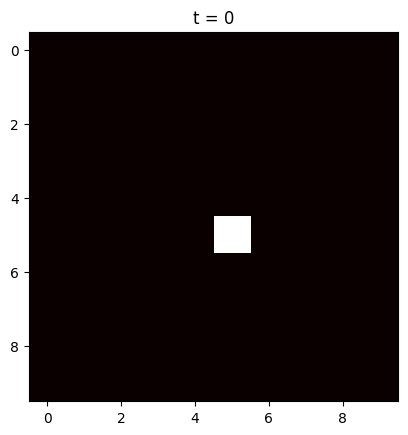

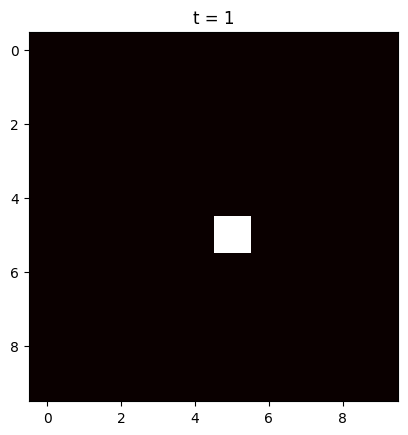

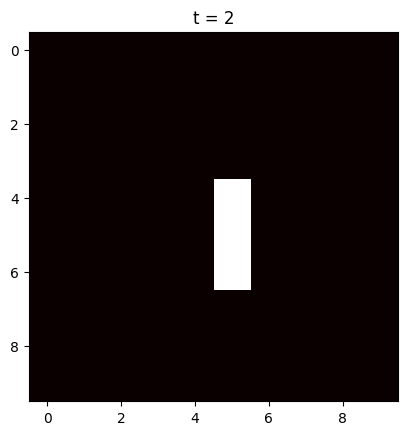

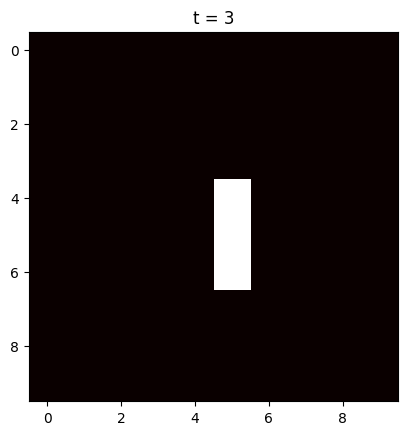

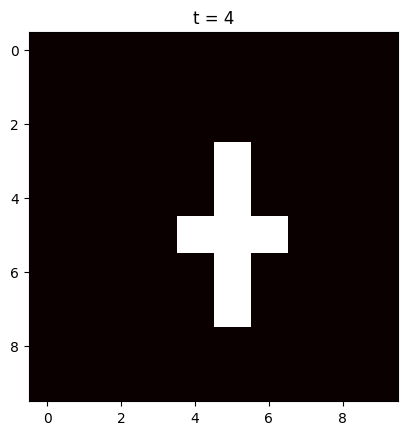

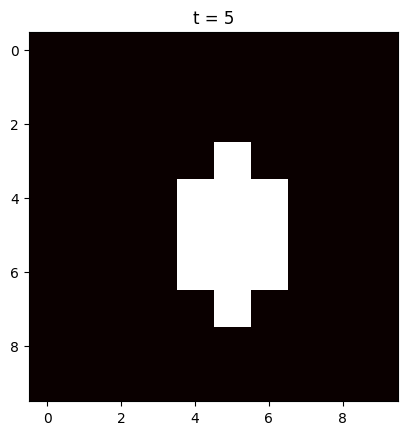

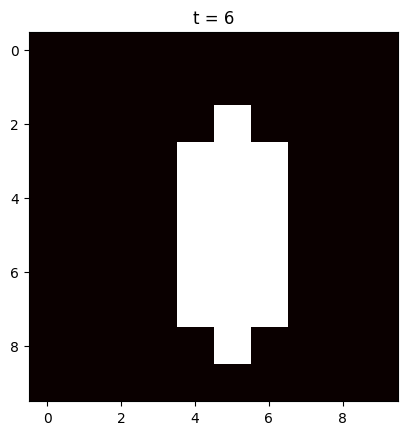

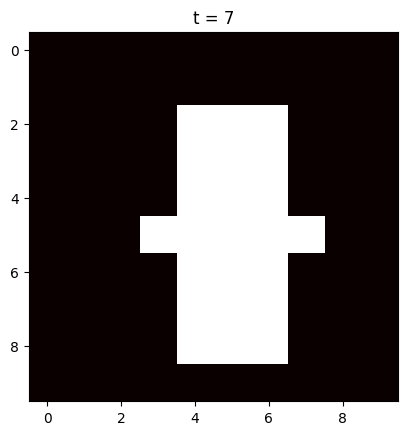

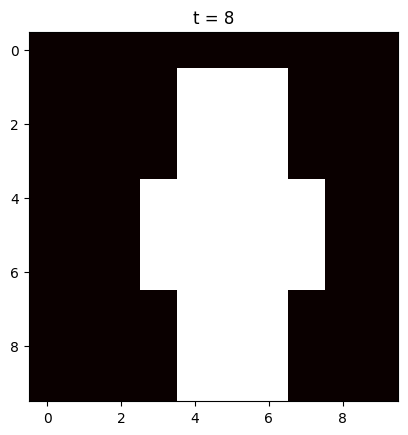

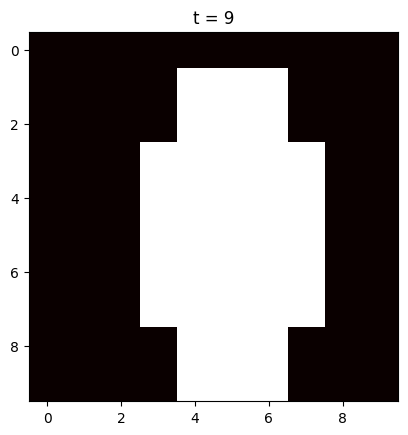

In [57]:
T = 10 

plt.figure()

for t in range(T):

    state = burning_loop(state, dF, dO, max_H, ignition_temp)

    plt.clf()
    plt.imshow(state[:, :, B], cmap='hot')
    #plt.imshow(state[:, :, F], cmap='Greens')
    plt.title(f"t = {t}")
    plt.pause(0.01)

plt.show()

## Adding Randomness

Each cell gets a random fuel $F \in [0,\max_F]$. To make it a bit more realistic I am creating clusters so that it is more like woods.

Another idea, which I have not finished implementing (commented out) is the randomness of ignition of neigbouring cells considering heat, fuel and oxygen.

In [58]:
T = 50

n, m = 100, 100
        
max_H = 1.0
max_F = 1.0
max_O = 1.0

state = np.zeros((n, m, 4))
H, F, O, B = 0, 1, 2, 3
 
state[:, :, O] = max_O  

start_row, start_col = n//2, m//2
state[start_row, start_col, H] = max_H
state[start_row, start_col, B] = 1

raw = np.random.uniform(0, 1, (n, m))

for _ in range(2):
    raw = (
        raw +
        np.roll(raw, 1, axis=0) +
        np.roll(raw, -1, axis=0) +
        np.roll(raw, 1, axis=1) +
        np.roll(raw, -1, axis=1)
    ) / 5

state[:, :, F] = max_F * raw

I am considering a bit of wind coming from the left:

In [59]:
mu_O = [0.2,0.2,0.1,0.3,0.2]
mu_H = [0.2,0.2,0.1,0.3,0.2]

if (sum(mu_O) != 1) or (sum(mu_H) != 1):
    print("Warning: The sum over the vector entries must be equal to one.")

dF = 0.02
dO = 0.05
ignition_temp = 0.3

### Simple (but better) Visualization

In [60]:
import matplotlib.animation as animation

In [61]:
def make_rgb(state):
    H, F, O, B = 0, 1, 2, 3

    fire = state[:, :, B]
    fuel = state[:, :, F]
    heat = state[:, :, H]

    rgb = np.zeros((state.shape[0], state.shape[1], 3))

    # red = fire + heat glow
    rgb[:, :, 0] = fire + 0.5 * heat

    # green = fuel
    rgb[:, :, 1] = fuel

    # blue = nothing (or smoke later 👀)
    rgb[:, :, 2] = 0

    return np.clip(rgb, 0, 1)

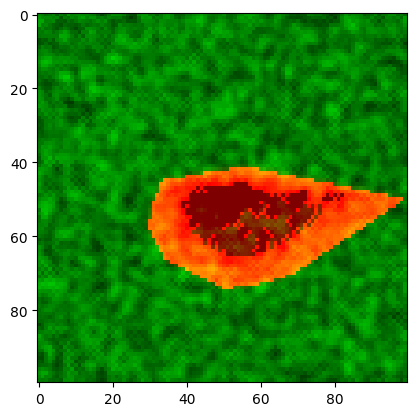

In [62]:
fig, ax = plt.subplots()
img = ax.imshow(make_rgb(state))

frames = []

for t in range(T):
    state = burning_loop(state, dF, dO, max_H, ignition_temp)

    frame = [ax.imshow(make_rgb(state), animated=True)]
    frames.append(frame)

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

ani.save("fire.gif", writer="pillow")

## Multiple starting cells

In [63]:
T = 50

n, m = 100, 100
        
max_H = 1.0
max_F = 1.0
max_O = 1.0

state = np.zeros((n, m, 4))
H, F, O, B = 0, 1, 2, 3
 
state[:, :, O] = max_O  

start_row, start_col = n//2, m//2
state[start_row, start_col, H] = max_H
state[start_row, start_col, B] = 1

state[5, 23, H] = max_H
state[5, 23, B] = 1

state[95, 64, H] = max_H
state[95, 64, B] = 1

raw = np.random.uniform(0, 1, (n, m))

for _ in range(2):
    raw = (
        raw +
        np.roll(raw, 1, axis=0) +
        np.roll(raw, -1, axis=0) +
        np.roll(raw, 1, axis=1) +
        np.roll(raw, -1, axis=1)
    ) / 5

state[:, :, F] = max_F * raw

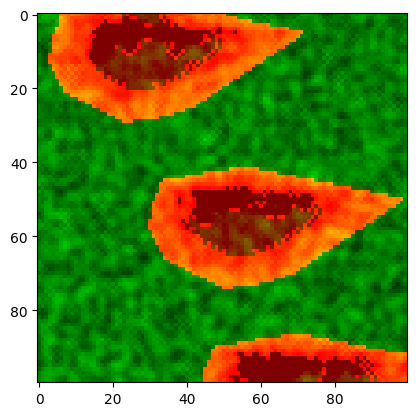

In [64]:
fig, ax = plt.subplots()
img = ax.imshow(make_rgb(state))

frames = []

for t in range(T):
    state = burning_loop(state, dF, dO, max_H, ignition_temp)

    frame = [ax.imshow(make_rgb(state), animated=True)]
    frames.append(frame)

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

ani.save("fire.gif", writer="pillow")